# Figure 16.

| Author  | Stanley A. Baronett  |
|---------|----------------------|
| Created |  09/23/2026          |
| Updated |  09/27/2026          |

Estimated energy consumed in kilowatt-hours (Section 3.2.2) as a function of grid resolution $N_{x,z}$.
As in Figures 13 and 15, circular or square markers show runs that implement $n_\mathrm{p} = 1$ particles or a dust fluid, respectively, while colors differentiate the codes.
For Idefix, filled squares with dashed lines or open squares with dotted lines show runs on Intel Skylake CPUs or a single NVIDIA A100 GPU, respectively, while the shaded area estimates the energy saved by the GPU, which widens with resolution.
The lowest-core-hour run in Table 3 (PLUTO, $n_\mathrm{p} = 1$, $512^2$) is included for reference.

512^2  CPU/GPU = 2.46x   PLUTO/GPU = 1.54x
1024^2 CPU/GPU = 3.72x


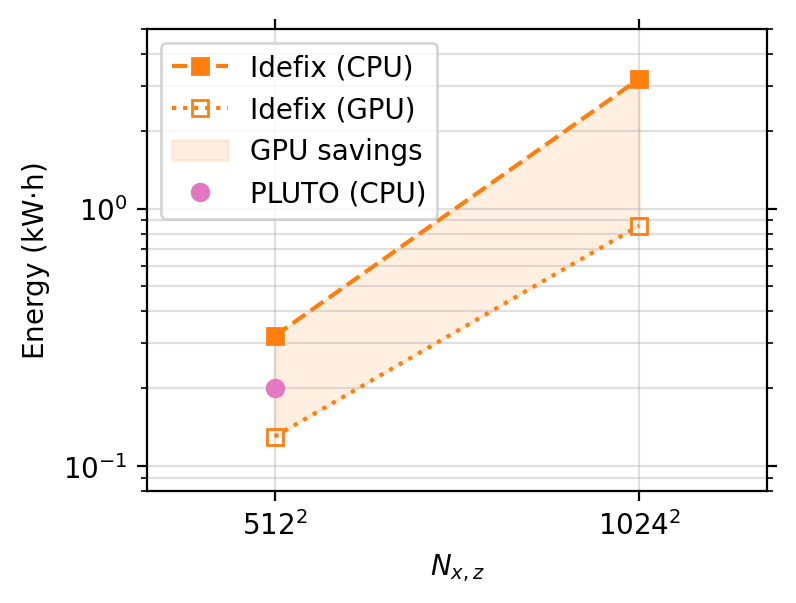

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Section 3.3.2 energy estimates (kW.h) at 512^2 and 1024^2.
x = np.array([0, 1])                         # categorical: 512^2, 1024^2
idefix_cpu = np.array([0.32, 3.2])           # Intel Skylake, 256/512 cores
idefix_gpu = np.array([0.13, 0.86])          # one NVIDIA A100
pluto_cpu  = np.array([0.20, np.nan])        # PLUTO np=1, Intel Skylake (512^2)

orange, pink = 'tab:orange', 'tab:pink'

fig, ax = plt.subplots(figsize=(4, 3), dpi=200)

# Series (Line2D takes markerfacecolor/markeredgecolor, not facecolor/edgecolor)
ax.plot(x, idefix_cpu, color=orange, ls='dashed', marker='s',
                 label='Idefix (CPU)')
ax.plot(x, idefix_gpu, color=orange, ls='dotted', marker='s',
                 markerfacecolor='none', markeredgecolor=orange,
                 label='Idefix (GPU)')
# Shade the GPU energy savings between the Idefix CPU and GPU curves.
ax.fill_between(x, idefix_gpu, idefix_cpu, color=orange, alpha=0.12,
                zorder=0, label='GPU savings')
ax.plot(x, pluto_cpu,  color=pink,  ls='none', marker='o',
                 label='PLUTO (CPU)')

# Format (match Panels 1-2 conventions)
ax.set(yscale='log', xlim=(-0.35, 1.35), ylim=(8e-2, 5),
       xlabel=r'$N_{x,z}$', ylabel=r'Energy (kW$\cdot$h)')
ax.set_xticks([0, 1])
ax.set_xticklabels([r'$512^2$', r'$1024^2$'])
ax.grid(which='both', alpha=0.4)
ax.tick_params(axis='y', which='both', right=True)
ax.tick_params(axis='x', which='both', top=True)
ax.legend()


# Diagnostics: efficiency ratios quoted in the text
print(f"512^2  CPU/GPU = {0.32/0.13:.2f}x   PLUTO/GPU = {0.20/0.13:.2f}x")
print(f"1024^2 CPU/GPU = {3.2/0.86:.2f}x")